In [1]:
import pandas as pd

df = pd.read_csv("reviews_dataset.csv")

df.head()

,review_id,user_id,product_id,product_name,product_category,rating,review_text,sentiment_score,sentiment_mismatch,verified_purchase,...,rating_std,review_length,days_to_first_review,review_date,is_fake,text_duplicate_count,text_similarity_score,word_count,exclamation_count,caps_ratio
0,1,677,29,Biography,Books,4,Fast shipping and the product exceeded my expe...,0.2250,0.2750,1,...,2.0,85,191,2025-11-26 21:22:49,0,38,0.0076,12,2,0.035294
1,2,56,42,Garden Hose,Garden,3,Average quality for the price. Nothing special...,0.1036,0.1036,1,...,2.0,62,420,2025-04-30 11:54:49,0,29,0.0058,9,0,0.032258
2,3,309,31,Building Blocks,Toys,4,Superb quality and excellent customer service....,0.7333,0.2333,1,...,2.0,80,174,2025-08-17 19:14:49,0,43,0.0086,11,1,0.037500
3,4,486,17,Dumbbells Set,Sports,5,Arrived on time and in perfect condition. Very...,0.8250,0.1750,1,...,2.0,71,300,2025-07-01 11:53:49,0,37,0.0074,11,0,0.028169
4,5,324,34,Puzzle Set,Toys,3,Product is okay. Does what it's supposed to do.,0.5000,0.5000,1,...,2.0,47,249,2025-11-03 17:51:49,0,20,0.0040,9,0,0.042553


In [2]:
df.columns

Index(['review_id', 'user_id', 'product_id', 'product_name',
       'product_category', 'rating', 'review_text', 'sentiment_score',
       'sentiment_mismatch', 'verified_purchase', 'account_age_days',
       'user_total_reviews', 'user_total_purchases', 'rating_std',
       'review_length', 'days_to_first_review', 'review_date', 'is_fake',
       'text_duplicate_count', 'text_similarity_score', 'word_count',
       'exclamation_count', 'caps_ratio'],
      dtype='str')

In [3]:
df["label"] = (df["sentiment_mismatch"] > 0.2).astype(int)

df[["review_text","label"]].head()

,review_text,label
0,Fast shipping and the product exceeded my expe...,1
1,Average quality for the price. Nothing special...,0
2,Superb quality and excellent customer service....,1
3,Arrived on time and in perfect condition. Very...,0
4,Product is okay. Does what it's supposed to do.,1


In [4]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\90532\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
stop_words = set(stopwords.words("english"))

In [6]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"[^\w\s]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [7]:
df["clean_text"] = df["review_text"].apply(clean_text)

df[["review_text","clean_text"]].head()

,review_text,clean_text
0,Fast shipping and the product exceeded my expe...,fast shipping product exceeded expectations fi...
1,Average quality for the price. Nothing special...,average quality price nothing special functional
2,Superb quality and excellent customer service....,superb quality excellent customer service buy ...
3,Arrived on time and in perfect condition. Very...,arrived time perfect condition satisfied customer
4,Product is okay. Does what it's supposed to do.,product okay supposed


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

y = df["label"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.782


In [11]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(accuracy_score(y_test, y_pred_nb))

0.794


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["clean_text"])

X_seq = tokenizer.texts_to_sequences(df["clean_text"])

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad = pad_sequences(X_seq, maxlen=100)

In [14]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [16]:
model.fit(
    X_train_dl,
    y_train_dl,
    epochs=3,
    batch_size=32
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.7275 - loss: 0.5238
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.7943 - loss: 0.3957
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.8173 - loss: 0.3496


In [17]:
loss, acc = model.evaluate(X_test_dl, y_test_dl)

print(acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8190 - loss: 0.3344
0.8190000057220459


In [18]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(Embedding(input_dim=5000, output_dim=64))

gru_model.add(GRU(64))

gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [19]:
gru_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=3,
    batch_size=32
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.7555 - loss: 0.4856
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.8133 - loss: 0.3610
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.8285 - loss: 0.3271


In [20]:
loss, gru_acc = gru_model.evaluate(X_test_dl, y_test_dl)

print(gru_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8150 - loss: 0.3216
0.8149999976158142


In [21]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential()

bilstm_model.add(Embedding(input_dim=5000, output_dim=64))

bilstm_model.add(Bidirectional(LSTM(64)))

bilstm_model.add(Dense(1, activation='sigmoid'))

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [22]:
bilstm_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=3,
    batch_size=32
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.7420 - loss: 0.5082
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7928 - loss: 0.3933
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8180 - loss: 0.3413


In [23]:
loss, bilstm_acc = bilstm_model.evaluate(
    X_test_dl,
    y_test_dl
)

print(bilstm_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8250 - loss: 0.3280
0.824999988079071


In [24]:
results = {
    "Logistic Regression": 0.782,
    "Naive Bayes": 0.794,
    "LSTM": acc,
    "GRU": gru_acc,
    "BiLSTM": bilstm_acc
}

print(results)

{'Logistic Regression': 0.782, 'Naive Bayes': 0.794, 'LSTM': 0.8190000057220459, 'GRU': 0.8149999976158142, 'BiLSTM': 0.824999988079071}


In [ ]:
# Turkish Product Review Analysis

In [26]:
df_tr = pd.read_csv("hb.csv")

df_tr.head()

,Rating (Star),Review,URL
0,5,3 yıldır tık demedi. :),https://www.hepsiburada.com/logitech-m175-kabl...
1,5,3 yıldır kullanıyorum müthiş,https://www.hepsiburada.com/logitech-m175-kabl...
2,4,Ürün bugün elime geçti çok fazla inceleme fırs...,https://www.hepsiburada.com/logitech-m175-kabl...
3,4,Almaya karar verdim. Hemencecik geldi. Keyifle...,https://www.hepsiburada.com/logitech-m175-kabl...
4,5,Günlük kullanımınızı çok çok iyi karsılıyor kı...,https://www.hepsiburada.com/logitech-m175-kabl...


In [27]:
df_tr.columns

Index(['Rating (Star)', 'Review', 'URL'], dtype='str')

In [28]:
df_tr = df_tr[["Rating (Star)", "Review"]]

In [29]:
df_tr = df_tr[df_tr["Rating (Star)"] != 3]

In [30]:
df_tr["label"] = df_tr["Rating (Star)"].apply(
    lambda x: 1 if x >= 4 else 0
)

In [31]:
df_tr[["Review", "Rating (Star)", "label"]].head()

,Review,Rating (Star),label
0,3 yıldır tık demedi. :),5,1
1,3 yıldır kullanıyorum müthiş,5,1
2,Ürün bugün elime geçti çok fazla inceleme fırs...,4,1
3,Almaya karar verdim. Hemencecik geldi. Keyifle...,4,1
4,Günlük kullanımınızı çok çok iyi karsılıyor kı...,5,1


In [32]:
stop_words_tr = set(stopwords.words("turkish"))

In [33]:
def clean_text_tr(text):

    text = str(text).lower()

    text = re.sub(r"[^\w\s]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words_tr]

    return " ".join(words)

In [34]:
df_tr["clean_text"] = df_tr["Review"].apply(clean_text_tr)

df_tr[["Review", "clean_text"]].head()

,Review,clean_text
0,3 yıldır tık demedi. :),3 yıldır tık demedi
1,3 yıldır kullanıyorum müthiş,3 yıldır kullanıyorum müthiş
2,Ürün bugün elime geçti çok fazla inceleme fırs...,ürün bugün elime geçti fazla inceleme fırsatım...
3,Almaya karar verdim. Hemencecik geldi. Keyifle...,almaya karar verdim hemencecik geldi keyifle k...
4,Günlük kullanımınızı çok çok iyi karsılıyor kı...,günlük kullanımınızı iyi karsılıyor kısaca mük...


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_tr = Tokenizer(num_words=10000)

tokenizer_tr.fit_on_texts(df_tr["clean_text"])

X_seq_tr = tokenizer_tr.texts_to_sequences(
    df_tr["clean_text"]
)

In [36]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad_tr = pad_sequences(
    X_seq_tr,
    maxlen=100
)

In [37]:
X_tr = X_pad_tr

y_tr = df_tr["label"]

In [38]:
from sklearn.model_selection import train_test_split

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    X_tr,
    y_tr,
    test_size=0.2,
    random_state=42
)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_tr = Sequential()

model_tr.add(
    Embedding(input_dim=10000, output_dim=64)
)

model_tr.add(LSTM(64))

model_tr.add(Dropout(0.5))

model_tr.add(Dense(1, activation='sigmoid'))

model_tr.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [40]:
model_tr.fit(
    X_train_tr,
    y_train_tr,
    epochs=3,
    batch_size=32
)

Epoch 1/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 552s 90ms/step - accuracy: 0.9603 - loss: 0.1209
Epoch 2/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 541s 89ms/step - accuracy: 0.9712 - loss: 0.0844
Epoch 3/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 532s 87ms/step - accuracy: 0.9774 - loss: 0.0674


In [41]:
loss_tr, acc_tr = model_tr.evaluate(
    X_test_tr,
    y_test_tr
)

print(acc_tr)

1522/1522 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.9688 - loss: 0.1009
0.9687679409980774


In [42]:
from tensorflow.keras.layers import GRU

gru_model_tr = Sequential()

gru_model_tr.add(
    Embedding(input_dim=10000, output_dim=64)
)

gru_model_tr.add(GRU(64))

gru_model_tr.add(Dense(1, activation='sigmoid'))

gru_model_tr.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [44]:
gru_model_tr.fit(
    X_train_tr,
    y_train_tr,
    epochs=3,
    batch_size=32
)

Epoch 1/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 404s 66ms/step - accuracy: 0.9863 - loss: 0.0421
Epoch 2/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 431s 71ms/step - accuracy: 0.9907 - loss: 0.0292
Epoch 3/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 478s 79ms/step - accuracy: 0.9938 - loss: 0.0200


In [45]:
loss_gru_tr, acc_gru_tr = gru_model_tr.evaluate(
    X_test_tr,
    y_test_tr
)

print(acc_gru_tr)

1522/1522 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9624 - loss: 0.1756
0.9623819589614868


In [46]:
from tensorflow.keras.layers import Bidirectional

In [47]:
bilstm_model_tr = Sequential()

bilstm_model_tr.add(
    Embedding(input_dim=10000, output_dim=64)
)

bilstm_model_tr.add(
    Bidirectional(LSTM(64))
)

bilstm_model_tr.add(
    Dense(1, activation='sigmoid')
)

bilstm_model_tr.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [48]:
bilstm_model_tr.fit(
    X_train_tr,
    y_train_tr,
    epochs=3,
    batch_size=32
)

Epoch 1/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 440s 71ms/step - accuracy: 0.9611 - loss: 0.1147
Epoch 2/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 430s 71ms/step - accuracy: 0.9724 - loss: 0.0799
Epoch 3/3
6088/6088 ━━━━━━━━━━━━━━━━━━━━ 389s 64ms/step - accuracy: 0.9787 - loss: 0.0623


In [49]:
loss_bilstm_tr, acc_bilstm_tr = bilstm_model_tr.evaluate(
    X_test_tr,
    y_test_tr
)

print(acc_bilstm_tr)

1522/1522 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9679 - loss: 0.1007
0.9679465889930725


In [50]:
turkish_results = {
    "LSTM": acc_tr,
    "GRU": acc_gru_tr,
    "BiLSTM": acc_bilstm_tr
}

print(turkish_results)

{'LSTM': 0.9687679409980774, 'GRU': 0.9623819589614868, 'BiLSTM': 0.9679465889930725}


In [53]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
english_results = {
    "Logistic Regression": 0.782,
    "Naive Bayes": 0.794,
    "LSTM": 0.819,
    "GRU": 0.815,
    "BiLSTM": 0.825
}

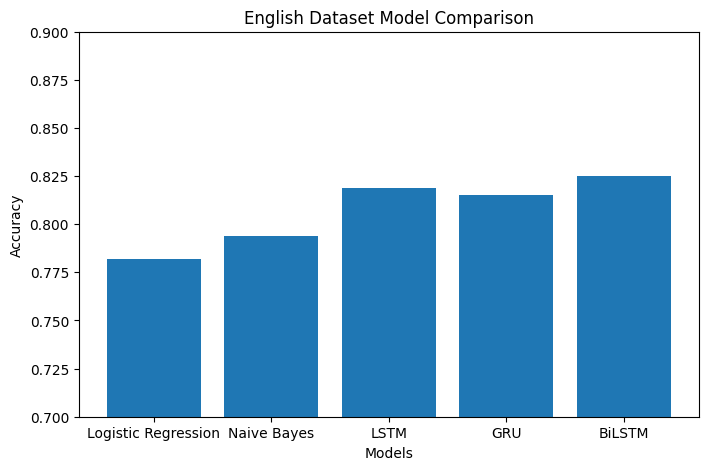

In [57]:
models_eng = list(english_results.keys())

acc_eng = list(english_results.values())

plt.figure(figsize=(8,5))

plt.bar(models_eng, acc_eng)

plt.title("English Dataset Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.7, 0.9)

plt.show()

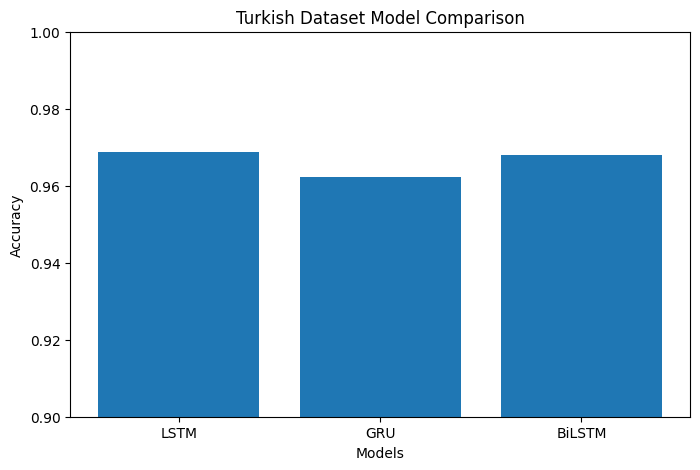

In [58]:
models_tr = list(turkish_results.keys())

acc_tr_list = list(turkish_results.values())

plt.figure(figsize=(8,5))

plt.bar(models_tr, acc_tr_list)

plt.title("Turkish Dataset Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.9, 1.0)

plt.show()

In [59]:
from sklearn.metrics import confusion_matrix

In [61]:
y_pred_prob = bilstm_model.predict(X_test_dl)

y_pred_class = (y_pred_prob > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


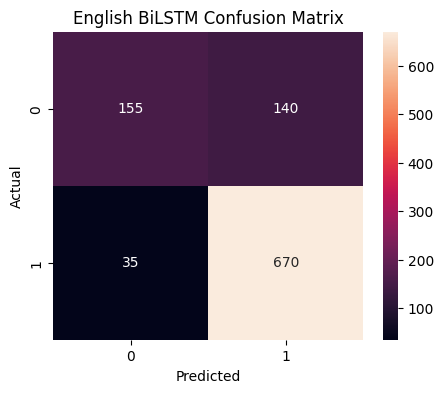

In [62]:
cm = confusion_matrix(y_test_dl, y_pred_class)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("English BiLSTM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [63]:
from sklearn.metrics import classification_report

In [64]:
print(classification_report(
    y_test_dl,
    y_pred_class
))

              precision    recall  f1-score   support

           0       0.82      0.53      0.64       295
           1       0.83      0.95      0.88       705

    accuracy                           0.82      1000
   macro avg       0.82      0.74      0.76      1000
weighted avg       0.82      0.82      0.81      1000



In [65]:
def predict_review(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=100)

    pred = bilstm_model.predict(padded)

    if pred > 0.5:
        return "Fake Review"
    else:
        return "Real Review"

In [66]:
print(predict_review("this product is amazing"))

print(predict_review("terrible quality waste of money"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Fake Review
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Fake Review


In [67]:
def predict_probability(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=100)

    pred = bilstm_model.predict(padded)

    print("Probability:", pred[0][0])

    if pred > 0.5:
        return "Fake Review"
    else:
        return "Real Review"

In [68]:
print(predict_probability("this product is amazing"))

print(predict_probability("terrible quality waste of money"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Probability: 0.54950607
Fake Review
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Probability: 0.97384614
Fake Review
